# Ελένη Λαζαρίδου ΑΕΜ:10859
# Αλέξανδρος Σουρουλλάς ΑΕΜ:10819

## Task D

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Task D - Setup and Data Loading
print("Task D: Custom Classifier for Large Dataset")
print("Loading training and test datasets")

#load datasetTV.csv (training set)
train_data_d = np.loadtxt('datasetTV.csv', delimiter=',')
print(f"Training data shape: {train_data_d.shape}")
print(f"Training set: {train_data_d.shape[0]} samples, {train_data_d.shape[1]-1} features")

#separate features and labels
X_train_d = train_data_d[:, :-1]  # All columns except last
y_train_d = train_data_d[:, -1]   # Last column is label

#load datasetTest.csv (test set - no labels)
test_data_d = np.loadtxt('datasetTest.csv', delimiter=',')
print(f"\nTest data shape: {test_data_d.shape}")
print(f"Test set: {test_data_d.shape[0]} samples, {test_data_d.shape[1]} features")

#check basic statistics
print("\n=== Data Statistics ===")
print(f"Training labels range: {int(y_train_d.min())} to {int(y_train_d.max())}")
print(f"Unique labels: {np.unique(y_train_d)}")
print(f"\nFeature statistics:")
print(f"  Min value: {X_train_d.min():.4f}")
print(f"  Max value: {X_train_d.max():.4f}")
print(f"  Mean: {X_train_d.mean():.4f}")
print(f"  Std: {X_train_d.std():.4f}")

Task D: Custom Classifier for Large Dataset
Loading training and test datasets
Training data shape: (8743, 225)
Training set: 8743 samples, 224 features

Test data shape: (6955, 224)
Test set: 6955 samples, 224 features

=== Data Statistics ===
Training labels range: 1 to 5
Unique labels: [1. 2. 3. 4. 5.]

Feature statistics:
  Min value: -1.6319
  Max value: 2.8668
  Mean: 0.2503
  Std: 0.5176


=== Data Exploration ===
Missing values in training set: 0
Missing values in test set: 0


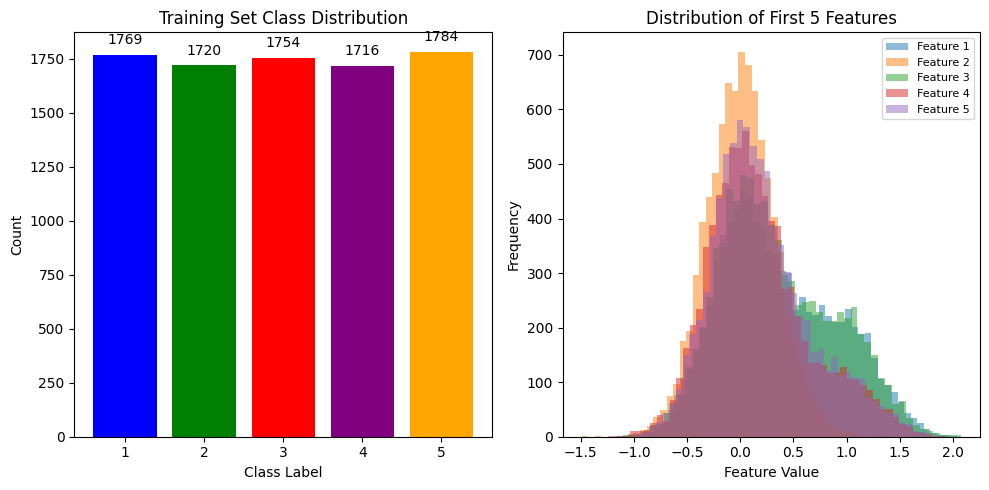


=== Feature Correlation Analysis ===
Correlation matrix shape: (20, 20)
Average absolute correlation: 0.0967


In [ ]:
# Cell 36: Data Exploration and Initial Analysis
print("=== Data Exploration ===")

# Check for missing values
missing_train = np.isnan(X_train_d).sum()
missing_test = np.isnan(test_data_d).sum()
print(f"Missing values in training set: {missing_train}")
print(f"Missing values in test set: {missing_test}")

# Check label distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
unique_labels, counts = np.unique(y_train_d, return_counts=True)
plt.bar(unique_labels, counts, color=['blue', 'green', 'red', 'purple', 'orange'])
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.title('Training Set Class Distribution')
plt.xticks(unique_labels)

for i, (label, count) in enumerate(zip(unique_labels, counts)):
    plt.text(label, count + 50, str(count), ha='center')

# Check feature distributions (first few features)
plt.subplot(1, 2, 2)
for i in range(min(5, X_train_d.shape[1])):
    plt.hist(X_train_d[:, i], bins=50, alpha=0.5, label=f'Feature {i+1}')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Distribution of First 5 Features')
plt.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Check feature correlations
print("\n=== Feature Correlation Analysis ===")
# Calculate correlation for first 20 features (to avoid memory issues)
n_features_check = min(20, X_train_d.shape[1])
corr_matrix = np.corrcoef(X_train_d[:, :n_features_check].T)
print(f"Correlation matrix shape: {corr_matrix.shape}")
print(f"Average absolute correlation: {np.abs(corr_matrix).mean():.4f}")

In [ ]:
# Feature Engineering and Preprocessing
print("=== Feature Engineering and Preprocessing ===")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

#handle any potential NaN values
if missing_train > 0 or missing_test > 0:
    print("Handling missing values...")
    # Fill with column mean
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    X_train_d = imputer.fit_transform(X_train_d)
    test_data_d = imputer.transform(test_data_d)

# standardization
print("Standardizing features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_d)
X_test_scaled = scaler.transform(test_data_d)

print(f"After scaling:")
print(f"  Training mean: {X_train_scaled.mean():.6f} (should be ~0)")
print(f"  Training std: {X_train_scaled.std():.6f} (should be ~1)")

# dimensionality Reduction (optional but helpful with 224 features)
print("\n=== Dimensionality Reduction ===")

# PCA to reduce dimensions while preserving variance
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_train_final = pca.fit_transform(X_train_scaled)
X_test_final = pca.transform(X_test_scaled)

print(f"PCA Results:")
print(f"  Original features: {X_train_scaled.shape[1]}")
print(f"  PCA components: {X_train_final.shape[1]}")
print(f"  Variance explained: {pca.explained_variance_ratio_.sum():.4f}")

=== Feature Engineering and Preprocessing ===
Standardizing features...
After scaling:
  Training mean: 0.000000 (should be ~0)
  Training std: 1.000000 (should be ~1)

=== Dimensionality Reduction ===
PCA Results:
  Original features: 224
  PCA components: 190
  Variance explained: 0.9500


In [ ]:
# Model Selection and Training
print("Model Selection and Training")

# Since we have 5 classes and potentially complex patterns,
# I'll use an ensemble method (Random Forest) which often works well

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initial Random Forest model
print("Training initial Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# Cross-validation to estimate performance
print("\nPerforming cross-validation...")
cv_scores = cross_val_score(rf_model, X_train_final, y_train_d, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Train on full training set
print("\nTraining on full training set...")
rf_model.fit(X_train_final, y_train_d)
print("Training complete!")

Model Selection and Training
Training initial Random Forest model...

Performing cross-validation...
Cross-validation scores: [0.8004574  0.7941681  0.7672956  0.76659039 0.77059497]
Mean CV accuracy: 0.7798 (+/- 0.0290)

Training on full training set...
Training complete!


In [ ]:
# Hyperparameter Tuning
print("Hyperparameter Tuning")

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4]
}

print("Performing grid search")

# Create and fit grid search
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_final, y_train_d)

print("\nGrid Search Results:")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Use best model
best_rf_model = grid_search.best_estimator_

In [ ]:
# Alternative Models with Proper Label Handling
print("Trying Alternative Models")

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Convert ALL labels to 0-based for consistency
# This is important because some algorithms expect 0-based labels
y_train_d_0based = y_train_d - 1  # Convert [1,2,3,4,5] to [0,1,2,3,4]

print(f"Label conversion:")
print(f"  Original labels: {np.unique(y_train_d)}")
print(f"  0-based labels:  {np.unique(y_train_d_0based)}")
print(f" We'll convert back to original labels for final predictions")

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', C=1.0, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42,
                            eval_metric='mlogloss', verbosity=0)
}

print("\nTraining and evaluating multiple models (using 0-based labels)")
results = {}
for name, model in models.items():
    # Quick train and cross-validate with 0-based labels
    try:
        scores = cross_val_score(model, X_train_final, y_train_d_0based, cv=3, scoring='accuracy')
        mean_score = scores.mean()
        std_score = scores.std()
        results[name] = mean_score
        print(f"{name:20} | Mean CV Accuracy: {mean_score:.4f} (+/- {std_score:.4f})")
    except Exception as e:
        print(f"{name:20} | Error: {str(e)[:60]}...")
        results[name] = 0

# Find best model
best_model_name = max(results, key=results.get)
print(f"\nBest model: {best_model_name} with accuracy: {results[best_model_name]:.4f}")

# Create final model based on best performer
if best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
elif best_model_name == 'SVM':
    final_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
elif best_model_name == 'Logistic Regression':
    final_model = LogisticRegression(max_iter=1000, random_state=42)
elif best_model_name == 'KNN':
    final_model = KNeighborsClassifier(n_neighbors=5)
elif best_model_name == 'XGBoost':
    final_model = XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )
else:
    # Default to Random Forest
    final_model = RandomForestClassifier(n_estimators=100, random_state=42)

print(f"\nSelected final model: {best_model_name}")

# Important: We need to train with 0-based labels
print("Training final model with 0-based labels")
final_model.fit(X_train_final, y_train_d_0based)
print("Final model trained")

# Store the label mapping for later use
label_mapping = {
    'original_to_0based': {1:0, 2:1, 3:2, 4:3, 5:4},
    '0based_to_original': {0:1, 1:2, 2:3, 3:4, 4:5}
}
print(f"\nLabel mapping stored for predictions.")

In [ ]:
# Model Evaluation with 0-based labels
print("Model Evaluation using best model from ")

# Since we don't have test labels, we'll use cross-validation and analyze training
# Also create a validation split from training data

from sklearn.model_selection import train_test_split

# Use 0-based labels for validation
y_train_d_0based = y_train_d - 1

# Split training data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_final, y_train_d_0based, test_size=0.2, random_state=42, stratify=y_train_d_0based
)

print(f"Training split: {X_train_split.shape[0]} samples")
print(f"Validation split: {X_val_split.shape[0]} samples")

# Train on training split (using 0-based labels)
final_model.fit(X_train_split, y_train_split)

# Predict on validation split
y_val_pred = final_model.predict(X_val_split)

# Convert back to original labels for display
y_val_split_original = y_val_split + 1
y_val_pred_original = y_val_pred + 1

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

accuracy = accuracy_score(y_val_split, y_val_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_val_split, y_val_pred, average='weighted')

print(f"\nValidation Results (0-based labels):")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print(f"\nValidation Results (original labels 1-5):")
print(f"  Accuracy:  {accuracy:.4f} (same)")

# Confusion Matrix (using 0-based labels for clarity)
print("\nConfusion Matrix (0-based labels 0-4):")
conf_matrix = confusion_matrix(y_val_split, y_val_pred)
print(conf_matrix)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Labels 0-4)')
plt.colorbar()
tick_marks = np.arange(5)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

# Add text annotations
thresh = conf_matrix.max() / 2
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, format(conf_matrix[i, j], 'd'),
                ha="center", va="center",
                color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('True label (0-4)')
plt.xlabel('Predicted label (0-4)')
plt.tight_layout()
plt.show()

In [ ]:
# Feature Importance Analysis
print("Feature Importance Analysis")

if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    print("Top 20 most important features (PCA components):")
    for i in range(min(20, len(importances))):
        print(f"  Component {indices[i]}: {importances[indices[i]]:.6f}")

    # Plot feature importances
    plt.figure(figsize=(10, 6))
    plt.title("Feature Importances (PCA Components)")
    plt.bar(range(min(20, len(importances))), importances[indices[:20]])
    plt.xlabel("PCA Component Index")
    plt.ylabel("Importance")
    plt.xticks(range(min(20, len(importances))), indices[:20])
    plt.tight_layout()
    plt.show()

    # Cumulative importance
    cumulative_importance = np.cumsum(np.sort(importances)[::-1])
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_importance, 'b-', linewidth=2)
    plt.xlabel('Number of Features')
    plt.ylabel('Cumulative Importance')
    plt.title('Cumulative Feature Importance')
    plt.grid(True, alpha=0.3)

    # Mark 95% importance threshold
    idx_95 = np.where(cumulative_importance >= 0.95)[0]
    if len(idx_95) > 0:
        plt.axvline(x=idx_95[0], color='r', linestyle='--', alpha=0.7)
        plt.text(idx_95[0], 0.5, f'95% at {idx_95[0]} features',
                rotation=90, va='center')

    plt.tight_layout()
    plt.show()

In [ ]:
# Generate Predictions for Test Set
print("=== Generating Predictions for Test Set ===")

# Important: Our model was trained on 0-based labels (0-4)
# So we need to predict with 0-based and convert back to original (1-5)

print("Retraining on full training set with 0-based labels...")
y_train_d_0based = y_train_d - 1  # Convert to 0-based
final_model.fit(X_train_final, y_train_d_0based)

# Predict on test set (will get 0-based predictions)
print("Making predictions on test set...")
test_predictions_0based = final_model.predict(X_test_final)

# Convert back to original labels (1-5)
test_predictions_original = test_predictions_0based + 1

print(f"\nPrediction Statistics (Original labels 1-5):")
unique_preds, counts_preds = np.unique(test_predictions_original, return_counts=True)
for label, count in zip(unique_preds, counts_preds):
    print(f"  Class {int(label)}: {count} predictions ({count/len(test_predictions_original)*100:.1f}%)")

print(f"\nPrediction Statistics (0-based labels 0-4):")
unique_preds_0, counts_preds_0 = np.unique(test_predictions_0based, return_counts=True)
for label, count in zip(unique_preds_0, counts_preds_0):
    print(f"  Class {int(label)}: {count} predictions ({count/len(test_predictions_0based)*100:.1f}%)")

# Save predictions to labelsX.npy
team_number = 45
filename = f'labels{team_number}.npy'

print(f"\nSaving predictions to {filename} (original labels 1-5)...")
np.save(filename, test_predictions_original)

# Verify the file can be loaded
loaded_predictions = np.load(filename)
print(f"Verification - loaded predictions shape: {loaded_predictions.shape}")
print(f"First 10 predictions: {loaded_predictions[:10]}")

print("\nPredictions saved successfully!")
print("Predictions are in original format (1-5) as required.")